<a href="https://colab.research.google.com/github/Nois12/AIFFEL_quest_rs/blob/main/Exploration/Ex04/Augmentation_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import random
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torch.optim as optim
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt

In [2]:
print(torch.__version__)
print(np.__version__)

2.11.0+cu128
2.0.2


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [4]:
!wget "http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar" -P ~/work/data_augmentation/data
!tar -xf ~/work/data_augmentation/data/images.tar -C ~/work/data_augmentation/data/

--2026-07-28 05:39:19--  http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar
Resolving vision.stanford.edu (vision.stanford.edu)... 171.64.68.10
Connecting to vision.stanford.edu (vision.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 793579520 (757M) [application/x-tar]
Saving to: ‘/root/work/data_augmentation/data/images.tar’

images.tar          100%[===================>] 756.82M  43.6MB/s    in 26s     

2026-07-28 05:39:46 (28.6 MB/s) - ‘/root/work/data_augmentation/data/images.tar’ saved [793579520/793579520]



In [5]:
dataset_dir = "~/work/data_augmentation/data/Images/"

transform = transforms.Compose([
    transforms.Resize((224, 224)),  # 크기 통일
    transforms.ToTensor(),  # Tensor 변환
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # 정규화 추가
])
full_dataset = ImageFolder(root=dataset_dir, transform=transform)

total_size = len(full_dataset)
train_size = int(0.583 * total_size)  # 약 12,000개
test_size = total_size - train_size   # 약 8,580개
ds_train, ds_test = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(ds_train, batch_size=32, shuffle=True)
test_loader = DataLoader(ds_test, batch_size=32, shuffle=False)
ds_info = {
    "num_classes": len(full_dataset.classes),
    "class_names": full_dataset.classes
}

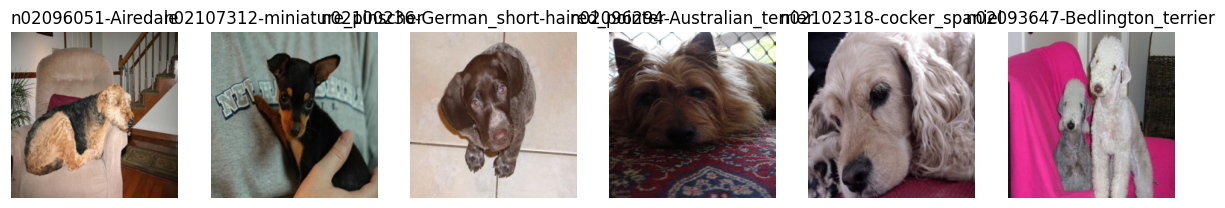

In [6]:
# DataLoader에서 일부 배치 가져오기
def show_examples(data_loader, class_names, num_images=6):
    data_iter = iter(data_loader)
    images, labels = next(data_iter)

    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        image = images[i].permute(1, 2, 0).numpy()  # (C, H, W) → (H, W, C)
        image = (image * 0.5) + 0.5
        image = np.clip(image, 0, 1)

        axes[i].imshow(image)
        axes[i].axis('off')
        axes[i].set_title(class_names[labels[i].item()])

    plt.show()

# 훈련 데이터 샘플 시각화
show_examples(train_loader, ds_info["class_names"])

In [7]:
def normalize_and_resize_img():
    return transforms.Compose([
        transforms.Resize((224, 224)),  # 크기 통일
        transforms.ToTensor(),  # Tensor 변환
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # 정규화 추가
    ])

In [8]:
def augment():
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2)
    ])

In [9]:
# 데이터셋을 가공하는 메인함수
def apply_normalize_on_dataset(dataset, is_test=False, batch_size=16, with_aug=False):
    transform = normalize_and_resize_img()

    if not is_test and with_aug:
        dataset.dataset.transform = transforms.Compose([
            *augment().transforms,
            *transform.transforms
        ])
    else:
        dataset.dataset.transform = transform

    return DataLoader(dataset, batch_size=batch_size, shuffle=not is_test, num_workers=2, pin_memory=True)

In [10]:
def augment2():
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),  # 좌우 반전
        transforms.RandomVerticalFlip(p=0.5),    # 상하 반전
        transforms.RandomRotation(degrees=(0, 90, 180, 270)),  # 90도 단위 회전
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),  # 밝기, 대비, 색상 조정
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # 랜덤 크롭 후 리사이즈
        transforms.Lambda(lambda img: torch.clamp(img, 0, 1))  # 0~1 값으로 클리핑
    ])

In [11]:
num_classes = len(ds_info["class_names"])
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet50.fc = nn.Linear(resnet50.fc.in_features, num_classes)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 183MB/s]


In [12]:
aug_resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
aug_resnet50.fc = nn.Linear(aug_resnet50.fc.in_features, num_classes)

In [13]:
ds_train_no_aug = apply_normalize_on_dataset(ds_train, with_aug=False)
ds_train_aug = apply_normalize_on_dataset(ds_train, with_aug=True)
ds_test = apply_normalize_on_dataset(ds_test, is_test=True)

In [14]:
%%time
EPOCH = 3
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet50.parameters(), lr=0.001)

def train(model, train_loader, test_loader, epochs):
    model.to(device)
    history = {'val_accuracy': []}
    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            # 진행 상황 출력 (10배치마다)
            if i % 10 == 0:
                batch_acc = 100. * correct / total
                print(f"  [Epoch {epoch+1}] batch {i}/{len(train_loader)} | loss: {loss.item():.4f} | acc so far: {batch_acc:.2f}%")

        train_acc = 100. * correct / total
        print(f"Epoch [{epoch+1}/{epochs}], Accuracy: {train_acc:.2f}%")

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        val_acc = 100. * correct / total
        history['val_accuracy'].append(val_acc)
        print(f"Validation Accuracy: {val_acc:.2f}%")
    return history

history_resnet50_no_aug = train(resnet50, ds_train_no_aug, ds_test, EPOCH)

  [Epoch 1] batch 0/750 | loss: 4.9076 | acc so far: 0.00%
  [Epoch 1] batch 10/750 | loss: 4.9498 | acc so far: 1.14%
  [Epoch 1] batch 20/750 | loss: 4.9039 | acc so far: 1.19%
  [Epoch 1] batch 30/750 | loss: 4.8624 | acc so far: 1.81%
  [Epoch 1] batch 40/750 | loss: 4.9920 | acc so far: 1.52%
  [Epoch 1] batch 50/750 | loss: 4.8787 | acc so far: 1.72%
  [Epoch 1] batch 60/750 | loss: 4.7458 | acc so far: 1.95%
  [Epoch 1] batch 70/750 | loss: 4.8471 | acc so far: 1.76%
  [Epoch 1] batch 80/750 | loss: 4.8056 | acc so far: 1.77%
  [Epoch 1] batch 90/750 | loss: 4.7464 | acc so far: 1.65%
  [Epoch 1] batch 100/750 | loss: 4.7760 | acc so far: 1.67%
  [Epoch 1] batch 110/750 | loss: 4.8235 | acc so far: 1.91%
  [Epoch 1] batch 120/750 | loss: 4.7132 | acc so far: 1.96%
  [Epoch 1] batch 130/750 | loss: 4.6526 | acc so far: 2.00%
  [Epoch 1] batch 140/750 | loss: 4.7773 | acc so far: 1.91%
  [Epoch 1] batch 150/750 | loss: 4.8092 | acc so far: 1.90%
  [Epoch 1] batch 160/750 | loss: 4

In [61]:
%%time
optimizer = optim.SGD(aug_resnet50.parameters(), lr=0.001)  # 이 줄 추가
history_resnet50_aug = train(aug_resnet50, ds_train_aug, ds_test, EPOCH)

  [Epoch 1] batch 0/750 | loss: 2.0332 | acc so far: 68.75%
  [Epoch 1] batch 10/750 | loss: 2.1823 | acc so far: 71.59%
  [Epoch 1] batch 20/750 | loss: 2.1319 | acc so far: 72.32%
  [Epoch 1] batch 30/750 | loss: 2.4993 | acc so far: 70.16%
  [Epoch 1] batch 40/750 | loss: 2.1923 | acc so far: 69.21%
  [Epoch 1] batch 50/750 | loss: 1.8992 | acc so far: 69.98%
  [Epoch 1] batch 60/750 | loss: 1.9099 | acc so far: 69.88%
  [Epoch 1] batch 70/750 | loss: 2.3439 | acc so far: 70.16%
  [Epoch 1] batch 80/750 | loss: 2.4970 | acc so far: 69.98%
  [Epoch 1] batch 90/750 | loss: 2.0366 | acc so far: 69.85%
  [Epoch 1] batch 100/750 | loss: 2.3846 | acc so far: 69.74%
  [Epoch 1] batch 110/750 | loss: 2.3717 | acc so far: 69.99%
  [Epoch 1] batch 120/750 | loss: 2.1374 | acc so far: 69.94%
  [Epoch 1] batch 130/750 | loss: 2.2491 | acc so far: 69.18%
  [Epoch 1] batch 140/750 | loss: 2.0062 | acc so far: 69.10%
  [Epoch 1] batch 150/750 | loss: 2.2462 | acc so far: 69.12%
  [Epoch 1] batch 1

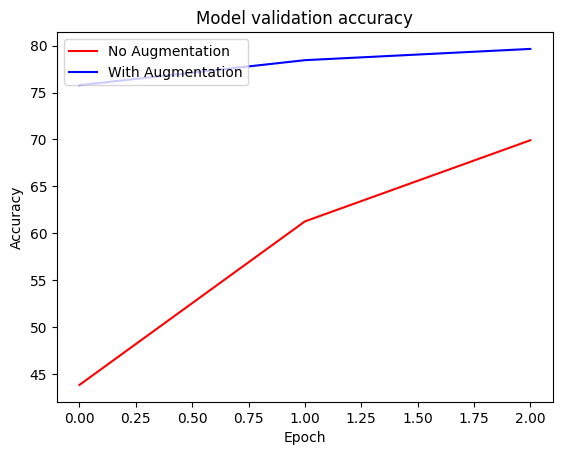

In [62]:
plt.plot(history_resnet50_no_aug['val_accuracy'], 'r', label='No Augmentation')
plt.plot(history_resnet50_aug['val_accuracy'], 'b', label='With Augmentation')
plt.title('Model validation accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

CutMix

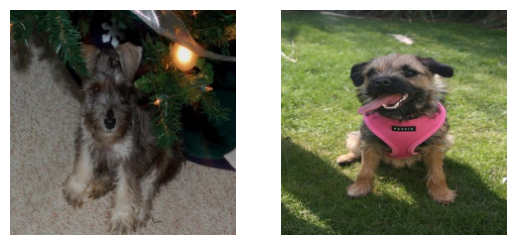

In [23]:
# 데이터셋에서 이미지 2개를 가져옵니다.
data_iter = iter(ds_train_no_aug)
images, labels = next(data_iter)

# 첫 번째 배치에서 두 개의 이미지 선택
image_a = images[0].permute(1, 2, 0).numpy()
image_b = images[1].permute(1, 2, 0).numpy()
label_a = labels[0].item()
label_b = labels[1].item()

# 정규화된 텐서를 다시 [0, 1] 범위로 조정
image_a = (image_a * 0.5) + 0.5
image_b = (image_b * 0.5) + 0.5

# 이미지 출력
plt.subplot(1, 2, 1)
plt.imshow(image_a)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image_b)
plt.axis('off')

plt.show()

In [24]:
def get_clip_box(image_a, image_b):
    # image.shape = (channel, height, width)
    image_size_x = image_a.shape[2]  # Width
    image_size_y = image_a.shape[1]  # Height

    # Get center of box
    x = torch.randint(0, image_size_x, (1,)).item()
    y = torch.randint(0, image_size_y, (1,)).item()

    width = max(1, int(image_size_x * torch.sqrt(1 - torch.rand(1)).item()))
    height = max(1, int(image_size_y * torch.sqrt(1 - torch.rand(1)).item()))

    # Clip box in image and get minmax bbox
    x_min = max(0, x - width // 2)
    y_min = max(0, y - height // 2)
    x_max = min(image_size_x, x + width // 2 + 1)
    y_max = min(image_size_y, y + height // 2 + 1)

    return x_min, y_min, x_max, y_max

x_min, y_min, x_max, y_max = get_clip_box(image_a, image_b)

print('x :', x_min, x_max)
print('y :', y_min, y_max)

x : 1 3
y : 0 75


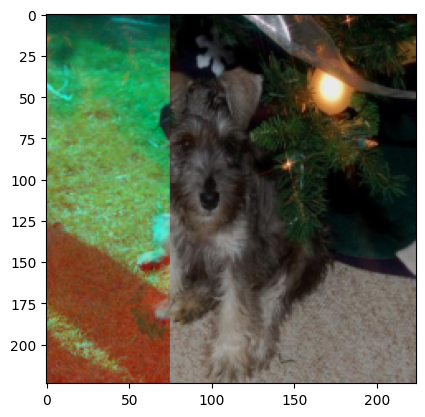

In [25]:
def mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max):
    # image.shape = (C, H, W)
    image_size_x = image_a.shape[2]  # Width
    image_size_y = image_a.shape[1]  # Height

    if isinstance(image_a, np.ndarray):
        image_a = torch.from_numpy(image_a).to(device)
    if isinstance(image_b, np.ndarray):
        image_b = torch.from_numpy(image_b).to(device)

    top = image_a[:, :y_min, :]
    middle_left = image_a[:, y_min:y_max, :x_min]
    middle_center = image_b[:, y_min:y_max, x_min:x_max]
    middle_right = image_a[:, y_min:y_max, x_max:]
    bottom = image_a[:, y_max:, :]

    top = top.to(device)
    middle_left = middle_left.to(device)
    middle_center = middle_center.to(device)
    middle_right = middle_right.to(device)
    bottom = bottom.to(device)

    # 중간 부분(왼쪽, 중앙, 오른쪽) 결합
    middle = torch.cat([middle_left, middle_center, middle_right], dim=2)

    # 전체 이미지 결합 (위 + 중간 + 아래)
    mixed_img = torch.cat([top, middle, bottom], dim=1)

    return mixed_img

mixed_img = mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max)

plt.imshow(mixed_img.cpu().numpy())
plt.show()

In [49]:
# mix two labels
def mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max, num_classes=120, img_size=224):
    image_size_x = img_size
    image_size_y = img_size

    # 바운딩 박스 비율 계산
    mixed_area = (x_max - x_min) * (y_max - y_min)
    total_area = image_size_x * image_size_y
    ratio = mixed_area / total_area

     # 원-핫 벡터 변환
    if isinstance(label_a, int):
        label_a = F.one_hot(torch.tensor(label_a), num_classes=num_classes).float()
    if isinstance(label_b, int):
        label_b = F.one_hot(torch.tensor(label_b), num_classes=num_classes).float()

    # 비율에 따라 라벨 혼합
    mixed_label = (1 - ratio) * label_a + ratio * label_b
    return mixed_label

# 예제 실행
mixed_label = mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max)
print(mixed_label)

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0030, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.9970, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

In [51]:
def cutmix(images, labels, prob=1.0, batch_size=16, img_size=224, num_classes=120):
    mixed_imgs = []
    mixed_labels = []

    for i in range(batch_size):
        image_a = images[i]
        label_a = labels[i]

        j = torch.randint(0, batch_size, (1,)).item()  # 다른 샘플 선택
        image_b = images[j]
        label_b = labels[j]

        # 바운딩 박스 생성
        x_min, y_min, x_max, y_max = get_clip_box(image_a, image_b)

        # 이미지 섞기
        mixed_imgs.append(mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max))
        mixed_labels.append(mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max, num_classes, img_size))

    # 텐서 변환
    mixed_imgs = torch.stack(mixed_imgs).reshape(batch_size, 3, img_size, img_size)
    mixed_labels = torch.stack(mixed_labels).reshape(batch_size, num_classes)

    return mixed_imgs, mixed_labels

MixUP

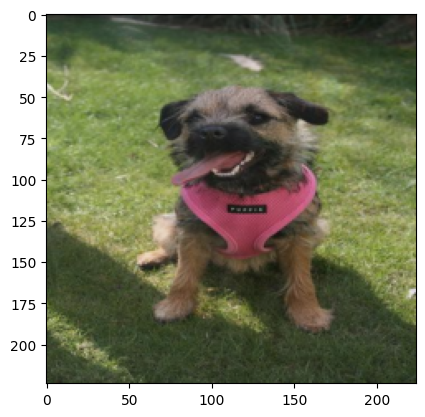

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.8623, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.1377, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

In [32]:
# function for mixup
def mixup_2_images(image_a, image_b, label_a, label_b, num_classes=120):
    ratio = torch.rand(1).item()  # 0~1 사이의 랜덤 값

    # 라벨 원핫 인코딩
    if isinstance(label_a, int):
        label_a = F.one_hot(torch.tensor(label_a), num_classes=num_classes).float()
    if isinstance(label_b, int):
        label_b = F.one_hot(torch.tensor(label_b), num_classes=num_classes).float()

    # 이미지와 라벨 혼합
    mixed_image = (1 - ratio) * image_a + ratio * image_b
    mixed_label = (1 - ratio) * label_a + ratio * label_b

    return mixed_image, mixed_label

# 예제 실행
mixed_img, mixed_label = mixup_2_images(image_a, image_b, label_a, label_b)

plt.imshow(mixed_img)
plt.show()

print(mixed_label)

In [33]:
def mixup(images, labels, batch_size=16, img_size=224, num_classes=120):
    mixed_imgs = []
    mixed_labels = []

    for i in range(batch_size):
        image_a = images[i]
        label_a = labels[i]

        # 랜덤하게 다른 이미지 선택
        j = torch.randint(0, batch_size, (1,)).item()
        image_b = images[j]
        label_b = labels[j]

        # Mixup 적용
        mixed_img, mixed_label = mixup_2_images(image_a, image_b, label_a, label_b, num_classes)

        mixed_imgs.append(mixed_img)
        mixed_labels.append(mixed_label)

    # 배치 차원 추가
    mixed_imgs = torch.stack(mixed_imgs).view(batch_size, 3, img_size, img_size)  # (B, C, H, W)
    mixed_labels = torch.stack(mixed_labels).view(batch_size, num_classes)  # (B, num_classes)

    return mixed_imgs, mixed_labels

CutMix와 MixUP 비교실험

In [34]:
# 이미지 정규화 및 크기 조정
def get_transform(mode="no_aug"):
    if mode == "basic_aug":
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
        ])
    else:  # no_aug
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
        ])

# 데이터셋 적용
def build_dataloaders(dataset_dir, batch_size=32, aug_mode="no_aug"):
    base_dataset = ImageFolder(dataset_dir, transform=None)

    train_size = int(0.8 * len(base_dataset))
    test_size = len(base_dataset) - train_size

    train_indices, test_indices = random_split(
        range(len(base_dataset)),
        [train_size, test_size]
    )

    train_dataset = torch.utils.data.Subset(
        ImageFolder(dataset_dir, transform=get_transform(aug_mode)),
        train_indices.indices
    )

    test_dataset = torch.utils.data.Subset(
        ImageFolder(dataset_dir, transform=get_transform("no_aug")),
        test_indices.indices
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=False
    )

    return train_loader, test_loader, base_dataset

In [43]:
def train_with_mix(model, train_loader, test_loader, epochs, mix_fn=None, num_classes=120):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.001)
    history = {'val_accuracy': [], 'train_loss': []}

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0
        epoch_loss = 0.0  # 추가
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            batch_size = images.size(0)

            if mix_fn is not None:
                labels_list = labels.cpu().tolist()
                mixed_images, targets = mix_fn(images, labels_list, batch_size=batch_size, num_classes=num_classes)
                mixed_images, targets = mixed_images.to(device), targets.to(device)
            else:
                mixed_images, targets = images, labels

            optimizer.zero_grad()
            outputs = model(mixed_images)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            if i % 10 == 0:
                print(f"  [Epoch {epoch+1}] batch {i}/{len(train_loader)} | loss: {loss.item():.4f}")

        train_acc = 100. * correct / total
        avg_loss = epoch_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        print(f"Epoch [{epoch+1}/{epochs}] Train Accuracy: {train_acc:.2f}%, Avg Loss: {avg_loss:.4f}")

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        val_acc = 100. * correct / total
        history['val_accuracy'].append(val_acc)
        print(f"Validation Accuracy: {val_acc:.2f}%")

    return history

In [52]:
mixup_resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
mixup_resnet50.fc = nn.Linear(mixup_resnet50.fc.in_features, num_classes)

cutmix_resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
cutmix_resnet50.fc = nn.Linear(cutmix_resnet50.fc.in_features, num_classes)

In [55]:
%%time
EPOCH = 3
history_mixup = train_with_mix(mixup_resnet50, ds_train_aug, ds_test, EPOCH, mix_fn=mixup, num_classes=num_classes)

  [Epoch 1] batch 0/750 | loss: 4.9052
  [Epoch 1] batch 10/750 | loss: 4.9366
  [Epoch 1] batch 20/750 | loss: 4.9152
  [Epoch 1] batch 30/750 | loss: 4.7277
  [Epoch 1] batch 40/750 | loss: 5.0262
  [Epoch 1] batch 50/750 | loss: 4.8159
  [Epoch 1] batch 60/750 | loss: 4.8145
  [Epoch 1] batch 70/750 | loss: 4.7825
  [Epoch 1] batch 80/750 | loss: 4.8949
  [Epoch 1] batch 90/750 | loss: 4.8063
  [Epoch 1] batch 100/750 | loss: 4.8558
  [Epoch 1] batch 110/750 | loss: 4.6034
  [Epoch 1] batch 120/750 | loss: 4.7457
  [Epoch 1] batch 130/750 | loss: 4.7320
  [Epoch 1] batch 140/750 | loss: 4.8146
  [Epoch 1] batch 150/750 | loss: 4.8508
  [Epoch 1] batch 160/750 | loss: 4.7975
  [Epoch 1] batch 170/750 | loss: 4.7166
  [Epoch 1] batch 180/750 | loss: 4.7085
  [Epoch 1] batch 190/750 | loss: 4.8231
  [Epoch 1] batch 200/750 | loss: 4.6548
  [Epoch 1] batch 210/750 | loss: 4.7362
  [Epoch 1] batch 220/750 | loss: 4.7441
  [Epoch 1] batch 230/750 | loss: 4.8029
  [Epoch 1] batch 240/750 |

In [56]:
%%time
history_cutmix = train_with_mix(cutmix_resnet50, ds_train_aug, ds_test, EPOCH, mix_fn=cutmix, num_classes=num_classes)

  [Epoch 1] batch 0/750 | loss: 4.0748
  [Epoch 1] batch 10/750 | loss: 3.9441
  [Epoch 1] batch 20/750 | loss: 3.9544
  [Epoch 1] batch 30/750 | loss: 3.9513
  [Epoch 1] batch 40/750 | loss: 3.8440
  [Epoch 1] batch 50/750 | loss: 4.0395
  [Epoch 1] batch 60/750 | loss: 4.0337
  [Epoch 1] batch 70/750 | loss: 4.1038
  [Epoch 1] batch 80/750 | loss: 3.9106
  [Epoch 1] batch 90/750 | loss: 3.9574
  [Epoch 1] batch 100/750 | loss: 3.7438
  [Epoch 1] batch 110/750 | loss: 3.9056
  [Epoch 1] batch 120/750 | loss: 4.0432
  [Epoch 1] batch 130/750 | loss: 3.7834
  [Epoch 1] batch 140/750 | loss: 3.7826
  [Epoch 1] batch 150/750 | loss: 3.8605
  [Epoch 1] batch 160/750 | loss: 3.7040
  [Epoch 1] batch 170/750 | loss: 3.8203
  [Epoch 1] batch 180/750 | loss: 3.9534
  [Epoch 1] batch 190/750 | loss: 3.8599
  [Epoch 1] batch 200/750 | loss: 4.0481
  [Epoch 1] batch 210/750 | loss: 3.7160
  [Epoch 1] batch 220/750 | loss: 3.8242
  [Epoch 1] batch 230/750 | loss: 3.7794
  [Epoch 1] batch 240/750 |

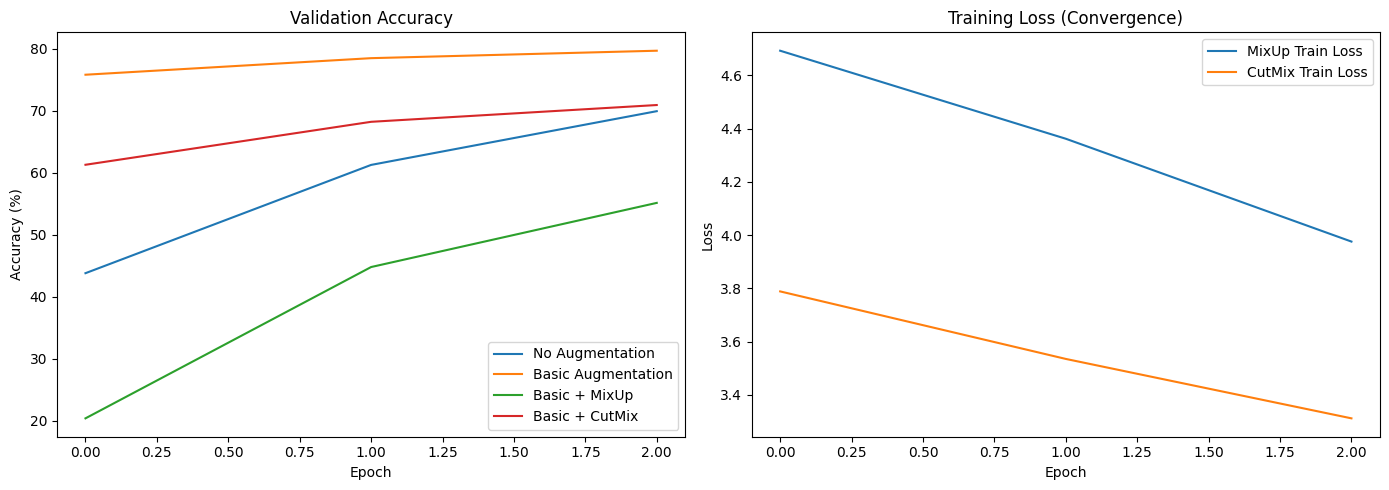

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 정확도 비교
axes[0].plot(history_resnet50_no_aug['val_accuracy'], label='No Augmentation')
axes[0].plot(history_resnet50_aug['val_accuracy'], label='Basic Augmentation')
axes[0].plot(history_mixup['val_accuracy'], label='Basic + MixUp')
axes[0].plot(history_cutmix['val_accuracy'], label='Basic + CutMix')
axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()

# Loss 비교
axes[1].plot(history_mixup['train_loss'], label='MixUp Train Loss')
axes[1].plot(history_cutmix['train_loss'], label='CutMix Train Loss')
axes[1].set_title('Training Loss (Convergence)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [64]:
print("No Aug:", history_resnet50_no_aug['val_accuracy'][-1])
print("Basic Aug:", history_resnet50_aug['val_accuracy'][-1])
print("MixUp:", history_mixup['val_accuracy'][-1])
print("CutMix:", history_cutmix['val_accuracy'][-1])

No Aug: 69.91377301328362
Basic Aug: 79.65509205313447
MixUp: 55.13866231647635
CutMix: 70.9042181309718


## Augmentation 기법별 성능 비교 및 분석

**(3 epoch 기준 실험 결과로, 짧은 학습 환경에서의 경향임을 전제로 해석)**

### - 결과 요약
| 기법 | 최종 Val Accuracy |
|---|---|
| No Augmentation | 69.91% |
| Basic Augmentation | 79.66% |
| Basic + MixUp | 55.14% |
| Basic + CutMix | 70.90% |

### - 해석
Basic Augmentation이 가장 높은 성능을 보였고, No Augmentation과 CutMix는 비슷한 수준이었다. MixUp은 가장 낮았는데, loss도 다른 기법보다 높게 유지되며 느리게 감소했다. 3 epoch이라는 짧은 학습에서는 MixUp처럼 강한 기법보다 약한 변형(Basic Augmentation)이 더 유리했던 것으로 보인다.


### - 결론
이번 환경에서는 Basic Augmentation(79.66%)이 가장 우수했고, CutMix(70.90%)가 뒤를 이었다. MixUp(55.14%)은 효과가 드러나기까지 더 많은 epoch이 필요해 짧은 학습에서는 불리했던 것으로 추정된다. Epoch을 늘리면 순위가 달라질 가능성이 있다.